<a href="https://colab.research.google.com/github/vyshnavps07-oss/corporate-ghg-emissions-analysis/blob/main/uhi_delhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import geemap

# Initialize Earth Engine
try:
    ee.Initialize(project='delhi-uhi-analysis-487108')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='delhi-uhi-analysis-487108')

# Load Delhi Boundary (ROI)
delhi_roi = ee.FeatureCollection("FAO/GAUL/2015/level1") \
              .filter(ee.Filter.eq('ADM1_NAME', 'Delhi'))

# Visualize Boundary
Map = geemap.Map()
Map.centerObject(delhi_roi, 10)
Map.addLayer(delhi_roi, {'color': 'red'}, 'Delhi Boundary')
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
!pip install geemap

Step 2: 2024 Analysis (LST, NDVI, NDBI)
We use the 90th percentile to capture the peak summer heat while avoiding cloud noise.

In [ ]:
landsat_2024 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(delhi_roi) \
    .filterDate('2024-04-01', '2024-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
    .reduce(ee.Reducer.percentile([90])) \
    .clip(delhi_roi)
print("successfully.")

successfully.


2024 LST

In [ ]:
thermal_2024 = landsat_2024.select('ST_B10_p90')
lst_2024 = thermal_2024.multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_2024')

lst_viz = {'min': 25, 'max': 50, 'palette': ['blue', 'green', 'yellow', 'orange', 'red']}
Map.addLayer(lst_2024, lst_viz, 'LST 2024')

2024 NDVI

In [ ]:
ndvi_2024 = landsat_2024.normalizedDifference(['SR_B5_p90', 'SR_B4_p90']).rename('NDVI_2024')
Map.addLayer(ndvi_2024, {'min': 0, 'max': 0.5, 'palette': ['white', 'green']}, 'NDVI 2024')
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

2024 NDBI

In [ ]:
# --- IMPROVED NDBI CALCULATION ---

def add_ndbi(image):
    # NDBI = (SWIR - NIR) / (SWIR + NIR)
    # Landsat 8: SWIR = B6, NIR = B5
    ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    return image.addBands(ndbi)

# 2024 NDBI calculation
collection_2024 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(delhi_roi) \
    .filterDate('2024-04-01', '2024-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
    .map(add_ndbi)

ndbi_2024 = collection_2024.select('NDBI').median().clip(delhi_roi)

Step 3: 2014 Analysis (LST, NDVI, NDBI)

In [ ]:
landsat_2014 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(delhi_roi) \
    .filterDate('2014-04-01', '2014-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
    .reduce(ee.Reducer.percentile([90])) \
    .clip(delhi_roi)

2014 LST

In [ ]:
thermal_2014 = landsat_2014.select('ST_B10_p90')
lst_2014 = thermal_2014.multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_2014')
Map.addLayer(lst_2014, lst_viz, 'LST 2014')

2014 NDVI

In [ ]:
ndvi_2014 = landsat_2014.normalizedDifference(['SR_B5_p90', 'SR_B4_p90']).rename('NDVI_2014')
Map.addLayer(ndvi_2014, {'min': 0, 'max': 0.5, 'palette': ['white', 'green']}, 'NDVI 2014')
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

2014 NDBI

In [ ]:
# --- IMPROVED NDBI CALCULATION ---

def add_ndbi(image):
    # NDBI = (SWIR - NIR) / (SWIR + NIR)
    # Landsat 8: SWIR = B6, NIR = B5
    ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    return image.addBands(ndbi)

# 2014 NDBI calculation
collection_2014 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(delhi_roi) \
    .filterDate('2014-04-01', '2014-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
    .map(add_ndbi)

ndbi_2014 = collection_2014.select('NDBI').median().clip(delhi_roi)

print("NDBI calculation updated with median composite.")

NDBI calculation updated with median composite.


Spatiotemporal Change Detection (Difference Map)

In [ ]:
# 1. Calculate Temperature Change (2024 - 2014)
lst_diff = lst_2024.subtract(lst_2014).rename('LST_Change')

# 2. Calculate Urban Expansion (NDBI 2024 - NDBI 2014)
ndbi_diff = ndbi_2024.subtract(ndbi_2014).rename('Urban_Expansion')

# Visualization: Red = Increase, Blue = Decrease, White = No Change
diff_viz = {'min': -5, 'max': 5, 'palette': ['blue', 'white', 'red']}

Map.addLayer(lst_diff, diff_viz, 'Temperature Increase (2014-2024)')
Map.addLayer(ndbi_diff, {'min': -0.2, 'max': 0.2, 'palette': ['blue', 'white', 'red']}, 'Urban Expansion (2014-2024)')
Map.addLayerControl()
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

Step 4: Temperature Change Detection (LST Difference)

In [ ]:
# Calculate the difference (Latest year - Baseline year)
lst_diff = lst_2024.subtract(lst_2014).rename('LST_Change_14_24')

# Visualization: Red = Warmer, Blue = Cooler, White = No Change
# Range -5 to 5 degrees Celsius is standard for decadal urban studies
diff_viz = {'min': -5, 'max': 5, 'palette': ['#0000ff', '#ffffff', '#ff0000']}

Map.addLayer(lst_diff, diff_viz, 'Temperature Change (2014-2024)')
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

Step 5: Urban Expansion Detection (NDBI Difference)



In [ ]:
# Calculate the change in built-up density
ndbi_diff = ndbi_2024.subtract(ndbi_2014).rename('Urban_Expansion')

# Visualization: Areas in Red show significant new urban development
ndbi_diff_viz = {'min': -0.2, 'max': 0.2, 'palette': ['#0000ff', '#ffffff', '#ff0000']}

Map.addLayer(ndbi_diff, ndbi_diff_viz, 'Urban Expansion (2014-2024)')
Map.addLayerControl()
Map

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…

Step 6: Decadal Statistical Comparison

In [ ]:
# Statistics Check
def get_final_val(image, label):
    val = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=delhi_roi.geometry(),
        scale=30,
        maxPixels=1e9
    ).getInfo()
    print(f"{label}: {list(val.values())[0]:.4f}")

print("--- REFINED DATA FOR GITHUB ---")
get_final_val(lst_2014, "Mean LST 2014")
get_final_val(lst_2024, "Mean LST 2024")
get_final_val(ndbi_2014, "Mean NDBI 2014 (Urban Density)")
get_final_val(ndbi_2024, "Mean NDBI 2024 (Urban Density)")

--- REFINED DATA FOR GITHUB ---
Mean LST 2014: 49.0467
Mean LST 2024: 50.0290
Mean NDBI 2014 (Urban Density): 0.0006
Mean NDBI 2024 (Urban Density): -0.0014


Step 9: Identify Heat Hotspots (Top 5 Areas

In [ ]:
# Create a sample of points to find the highest increase
hotspot_samples = lst_diff.sample(
    region=delhi_roi,
    scale=30,
    numPixels=5000,
    geometries=True
)

# Sort by the temperature change and get the top 5
top_hotspots = hotspot_samples.sort('LST_Change_14_24', False).limit(5)

# Add hotspots to the map as bright yellow dots
Map.addLayer(top_hotspots, {'color': 'yellow'}, 'Top 5 Heat Hotspots')
Map.centerObject(top_hotspots, 12)

# Print the coordinates or names if available
print("Coordinates of Top 5 Heat Hotspots (2014-2024):")
print(top_hotspots.getInfo()['features'])

Coordinates of Top 5 Heat Hotspots (2014-2024):
[{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [77.31354817313579, 28.518253088862284]}, 'id': '4056', 'properties': {'LST_Change_14_24': 15.716055960000062}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [77.32049875447862, 28.51532485037074]}, 'id': '3794', 'properties': {'LST_Change_14_24': 14.328339839999956}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [77.25182414940464, 28.689592634254744]}, 'id': '4146', 'properties': {'LST_Change_14_24': 14.143766760000005}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [77.31874271618179, 28.523573520876198]}, 'id': '3021', 'properties': {'LST_Change_14_24': 14.017300019999993}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [77.23589315848255, 28.730789071972858]}, 'id': '1420', 'properties': {'LST_Change_14_24': 12.738960539999994}}]


1. Neighborhood-wise Zonal Statistics

In [ ]:
# Calculate mean change for each feature in the ROI (if you have sub-districts)
zonal_stats = lst_diff.reduceRegions(
    collection=delhi_roi,
    reducer=ee.Reducer.mean(),
    scale=30
)

# This adds a 'mean' column to your data showing the specific rise in that sub-zone

2. Multi-Parameter Sampling (The "Feature Set")
When you export your hotspots, don't just export the temperature. Export the NDVI (greenery) and NDBI (buildings) for those same points. This allows you to prove the correlation in your final report.

In [ ]:
# Combine all layers into one "Data Cube"
data_stack = lst_2024.addBands(ndvi_2024).addBands(ndbi_2024).addBands(lst_diff)

# Sample the data at your hotspot locations
final_samples = data_stack.sampleRegions(
    collection=top_hotspots,
    properties=[],
    scale=30
)

3. Classification of "Change Type"
You can add a column that labels each hotspot. For example, if NDBI increased and NDVI decreased, the CSV will label that point as "Urban Growth."
Updated Code to Run Before CSV Export
Run this block to create a "Master Data Frame" that includes all parameters:

In [ ]:
# 1. Stack all relevant bands for 2024
master_stack = lst_2024.addBands(ndvi_2024).addBands(ndbi_2024).addBands(lst_diff)

# 2. Extract data for the top hotspots
detailed_samples = master_stack.sampleRegions(
    collection=top_hotspots,
    scale=30,
    geometries=True
).getInfo()

# 3. Process into a clean table
import pandas as pd

rows = []
for f in detailed_samples['features']:
    props = f['properties']
    props['longitude'] = f['geometry']['coordinates'][0]
    props['latitude'] = f['geometry']['coordinates'][1]
    rows.append(props)

master_df = pd.DataFrame(rows)

# Rename columns for clarity
master_df = master_df.rename(columns={
    'LST_2024': 'Temp_2024_C',
    'LST_Change_14_24': 'Temp_Rise_C',
    'NDVI_2024': 'Green_Index',
    'NDBI': 'Urban_Index'
})

print(master_df.head())

   Temp_2024_C  Temp_Rise_C  Urban_Index  Green_Index  longitude   latitude
0    57.941597    15.716056    -0.006628     0.036050  77.313550  28.518321
1    55.094387    14.328340     0.034104     0.085409  77.320557  28.515357
2    50.746665    14.143767    -0.010931     0.107771  77.251836  28.689720
3    54.099743    14.017300    -0.017951     0.133055  77.318670  28.523442
4    49.936595    12.738961    -0.007706     0.108856  77.235935  28.730683


1. Statistical Correlation (Heatmap)
Before exporting, it is vital to see how the different indices (Temperature, Greenery, and Urban Density) relate to each other. This confirms the "Urban Heat Island" logic: as the Urban Index goes up, the Temperature Rise should also go up.

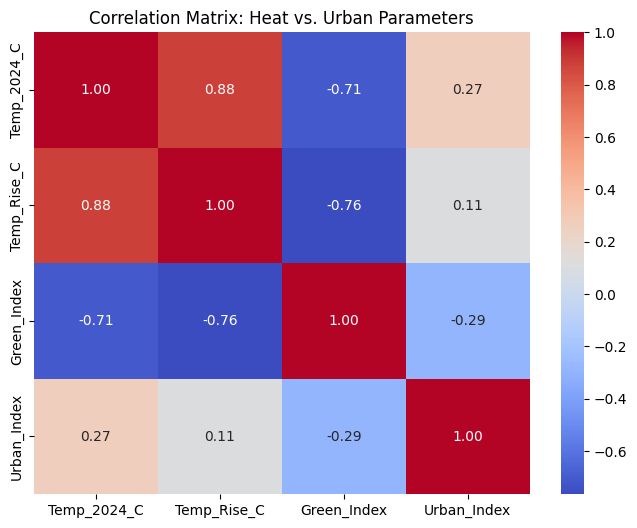

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr = master_df[['Temp_2024_C', 'Temp_Rise_C', 'Green_Index', 'Urban_Index']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Heat vs. Urban Parameters')
plt.show()

2. Side-by-Side Visual Comparison
For your final report, a side-by-side view of 2014 vs 2024 is the most powerful way to show the "Spatiotemporal" change. We will use the linked_maps feature.

In [ ]:
# Define layers
left_layer = geemap.ee_tile_layer(lst_2014, lst_viz, 'LST 2014')
right_layer = geemap.ee_tile_layer(lst_2024, lst_viz, 'LST 2024')

# Create the linked map
# Note: Zoom and Center are set for Delhi
Map_Compare = geemap.linked_maps(
    rows=1, cols=2, height='500px',
    layers=[left_layer, right_layer],
    labels=['Summer 2014', 'Summer 2024'],
    center=[28.6139, 77.2090], zoom=10
)

Map_Compare

GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

In [ ]:
from google.colab import output
output.enable_custom_widget_manager() # Ensure this is enabled

# Create the Map
Map_Split = geemap.Map()

# Define the two layers
left_layer = geemap.ee_tile_layer(lst_2014, lst_viz, 'LST 2014')
right_layer = geemap.ee_tile_layer(lst_2024, lst_viz, 'LST 2024')

# Create the Split Panel
Map_Split.split_map(left_layer, right_layer)

# Center on Delhi and Display
Map_Split.centerObject(delhi_roi, 10)
Map_Split

Map(center=[28.646455931994893, 77.10900424302301], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
# 1. Enable widgets
from google.colab import output
output.enable_custom_widget_manager()

# 2. Create the Map
Map_Split = geemap.Map()

# 3. Define the layers
left_layer = geemap.ee_tile_layer(lst_2014, lst_viz, 'LST 2014')
right_layer = geemap.ee_tile_layer(lst_2024, lst_viz, 'LST 2024')

# 4. Add the Split Panel
Map_Split.split_map(left_layer, right_layer)

# 5. Add a Colorbar Legend
# We use the same min/max and palette from your lst_viz
Map_Split.add_colorbar(
    vis_params=lst_viz,
    label="Land Surface Temperature (°C)",
    layer_name="LST Scale",
    orientation="horizontal",
    transparent_bg=True
)

# 6. Add a custom Floating Text Legend for Clarity
legend_dict = {
    '2014 Summer': 'Left Side',
    '2024 Summer': 'Right Side'
}

# To satisfy the 'list of tuples' requirement for colors,
# and to display the descriptive text, we will combine the key and value
# from the original legend_dict into new keys.
legend_keys = [
    f"{key}: {value}" for key, value in legend_dict.items()
]

# Provide transparent colors as RGB tuples. The alpha value is not directly used for hex conversion.
# Since we want transparent swatches, the actual RGB values don't matter as long as they are valid.
transparent_colors = [(0, 0, 0)] * len(legend_keys) # Use RGB (3 elements) instead of RGBA (4 elements)

Map_Split.add_legend(
    title="Comparison Period",
    keys=legend_keys,
    colors=transparent_colors
)

# 7. Center and Display
Map_Split.centerObject(delhi_roi, 10)
Map_Split

Map(center=[28.646455931994893, 77.10900424302301], controls=(ZoomControl(options=['position', 'zoom_in_text',…

3. Final Export to CSV
Finally, save your master data frame to a CSV file. This file contains the "evidence" for your entire study.

In [ ]:
# Export to Google Colab local storage
master_df.to_csv('Delhi_Hotspot_Analysis_2014_2024.csv', index=False)

print("Analysis Complete. CSV file saved.")

Analysis Complete. CSV file saved.


In [ ]:
import ee
import geemap
from google.colab import output

# 1. Enable the widget manager (Crucial for Colab)
output.enable_custom_widget_manager()

# 2. Re-initialize the connection
try:
    ee.Initialize(project='delhi-uhi-analysis-487108')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='delhi-uhi-analysis-487108')

# 3. Re-create the Map object to refresh the view
Map_Refresh = geemap.Map()

# 4. Add your saved layers back
left_layer = geemap.ee_tile_layer(lst_2014, lst_viz, 'LST 2014')
right_layer = geemap.ee_tile_layer(lst_2024, lst_viz, 'LST 2024')

# 5. Create the Split Panel
Map_Refresh.split_map(left_layer, right_layer)
Map_Refresh.centerObject(delhi_roi, 10)

# 6. Final display command
Map_Refresh

Map(center=[28.646455931994893, 77.10900424302301], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
# 1. Initialize Map
Map_Full = geemap.Map()
Map_Full.centerObject(delhi_roi, 10)

# 2. Define Visualization Parameters
lst_viz = {'min': 25, 'max': 55, 'palette': ['blue', 'green', 'yellow', 'orange', 'red']}
ndvi_viz = {'min': 0, 'max': 0.5, 'palette': ['white', 'green']}
ndbi_viz = {'min': -0.1, 'max': 0.3, 'palette': ['white', 'black', 'red']}

# --- ADD 2014 LAYERS ---
Map_Full.addLayer(lst_2014, lst_viz, '1. LST 2014 (Old Heat)')
Map_Full.addLayer(ndvi_2014, ndvi_viz, '2. NDVI 2014 (Old Greenery)')
Map_Full.addLayer(ndbi_2014, ndbi_viz, '3. NDBI 2014 (Old Urban)')

# --- ADD 2024 LAYERS ---
Map_Full.addLayer(lst_2024, lst_viz, '4. LST 2024 (New Heat)')
Map_Full.addLayer(ndvi_2024, ndvi_viz, '5. NDVI 2024 (New Greenery)')
Map_Full.addLayer(ndbi_2024, ndbi_viz, '6. NDBI 2024 (New Urban)')

# --- ADD CHANGE LAYER ---
Map_Full.addLayer(lst_diff, {'min': -5, 'max': 5, 'palette': ['blue', 'white', 'red']}, '7. Temperature Change (14-24)')

# 3. Add Layer Control (Toggle Menu)
Map_Full.addLayerControl()

# 4. Display
Map_Full

Map(center=[28.646455931994893, 77.10900424302301], controls=(WidgetControl(options=['position', 'transparent_…